/tmp/ipykernel_1982492/3320320638.py:49: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  merged_df[f'diff_{offset}'] = merged_df[f'ref_predicted_{offset}'] - merged_df[f'alt_predicted_{offset}']
/tmp/ipykernel_1982492/3320320638.py:49: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  merged_df[f'diff_{offset}'] = merged_df[f'ref_predicted_{offset}'] - merged_df[f'alt_predicted_{offset}']
/tmp/ipykernel_1982492/3320320638.py:49: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` m

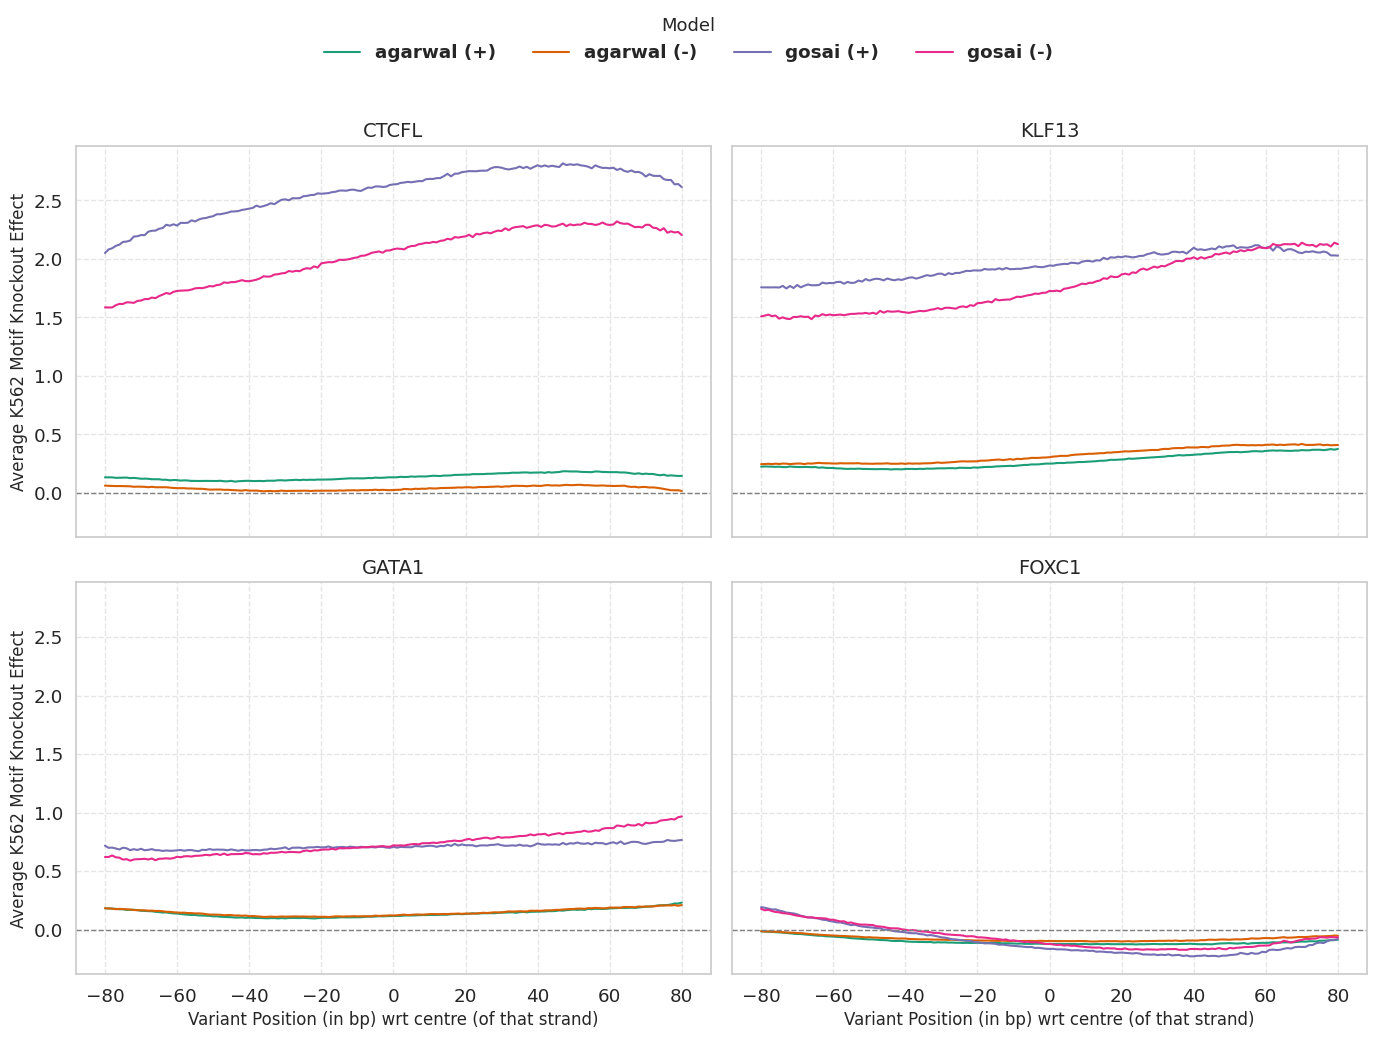

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns
sns.set(style="whitegrid", font_scale=1.2)

file_paths = {
    "agarwal (+)": "/scratch/st-cdeboer-1/sambina/mpra_position_paper/figure_2/human_motifs/output/predicted_k562_regulator_knockout_agarwal.csv",
    "agarwal (-)": "/scratch/st-cdeboer-1/sambina/mpra_position_paper/figure_2/human_motifs/output/predicted_k562_regulator_knockout_agarwal_rc.csv",
    "gosai (+)": "/scratch/st-cdeboer-1/sambina/mpra_position_paper/figure_2/human_motifs/output/predicted_k562_regulator_knockout.csv",
    "gosai (-)": "/scratch/st-cdeboer-1/sambina/mpra_position_paper/figure_2/human_motifs/output/predicted_k562_regulator_knockout_rc.csv"
}

# TFs of interest
target_motifs = ["CTCFL", "KLF13", "GATA1", "FOXC1"]
offsets = range(-80, 81)


colors = {
    "agarwal (+)": "#1b9e77",  # teal
    "agarwal (-)": "#d95f02",  # orange-gold
    "gosai (+)": "#7570b3",    # sky blue
    "gosai (-)": "#e7298a"     # pink-crimson
}


# Set up 2x2 panel for the TFs
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
axes = axes.flatten()

for i, target_motif in enumerate(target_motifs):
    ax = axes[i]
    diff_by_model = {}

    for label, path in file_paths.items():
        df = pd.read_csv(path)
        df['allele'] = df['motif_name'].str.extract(r'_(ref|alt)$')
        df['motif_group'] = df['motif_name'].str.replace(r'_alt$', '', regex=True)

        ref_df = df[df['allele'] != 'alt'].copy()
        alt_df = df[df['allele'] == 'alt'].copy()

        ref_df = ref_df.rename(columns={col: f"ref_{col}" for col in ref_df.columns if col not in ['seq_id', 'motif_group', 'motif_name']})
        alt_df = alt_df.rename(columns={col: f"alt_{col}" for col in alt_df.columns if col not in ['seq_id', 'motif_group', 'motif_name']})

        merged_df = pd.merge(ref_df, alt_df, on=['seq_id', 'motif_group'], how='inner')

        for offset in offsets:
            merged_df[f'diff_{offset}'] = merged_df[f'ref_predicted_{offset}'] - merged_df[f'alt_predicted_{offset}']

        avg_diff = merged_df[merged_df['motif_group'].str.startswith(target_motif)]
        diff_cols = [f'diff_{offset}' for offset in offsets]
        avg_vals = avg_diff[diff_cols].mean()

        # Flip offsets for (+) strand models
        if "(+)" in label:
            flipped_cols = {f'diff_{offset}': f'diff_{-offset}' for offset in offsets}
            avg_vals = avg_vals.rename(index=flipped_cols)

        # Reorder consistently from -80 to +80
        ordered_index = [f'diff_{offset}' for offset in offsets]
        avg_vals = avg_vals.reindex(ordered_index)

        diff_by_model[label] = avg_vals.values

    # Plot on this subplot
    for label, y_vals in diff_by_model.items():
        ax.plot(offsets, y_vals, label=label, color=colors.get(label))

    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    ax.set_title(target_motif, fontsize=14)
    ax.grid(True, linestyle='--', alpha=0.5)

    if i in [2, 3]:
        ax.set_xlabel("Variant Position (in bp) wrt centre (of that strand)", fontsize=12)
    if i in [0, 2]:
        ax.set_ylabel("Average K562 Motif Knockout Effect", fontsize=12)

handles, labels = axes[0].get_legend_handles_labels()
# fig.legend(handles, labels, title="Model", bbox_to_anchor=(0.5, 1.02), loc="upper center", ncol=4, fontsize=11, title_fontsize=12, frameon=False)
# Global legend with bold font
fig.legend(handles, labels, title="Model", bbox_to_anchor=(0.5, 1.05), loc="upper center", ncol=4,
           fontsize=12, title_fontsize=13, frameon=False,
           prop={'weight': 'bold'})

fig.savefig("/scratch/st-cdeboer-1/sambina/mpra_position_paper/figure_2/human_motifs/output/selected_Tfs.svg", format="svg")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [5]:
data = pd.read_csv("/scratch/st-cdeboer-1/sambina/mpra_position_paper/figure_2/human_motifs/output/predicted_k562_regulator_knockout_rc.csv")
data_df = data.tail(2)
data_df.to_csv("/scratch/st-cdeboer-1/sambina/mpra_position_paper/figure_2/human_motifs/output/subsampled_agarwal.csv")

In [ ]:
data = pd.read_csv("/scratch/st-cdeboer-1/sambina/mpra_position_paper/figure_2/human_motifs/output/predicted_k562_regulator_knockout.csv")
data_df = data.tail(2)
data_df.to_csv("/scratch/st-cdeboer-1/sambina/mpra_position_paper/figure_2/human_motifs/output/subsampled_agarwal_for.csv")

seq_-80

ACTGGCCGCTTGACGA

CTCCAGACCGTNNNNNNNNNNNNNNNCCGTTGGTCATAGAGCAACAACCCAGGCAACTCCTCGAGCGTATTATACCG
TACGGCGTACTCTTTCTGAGGGGGCTGCATGGGACGGGAGATTAAAATGTTAATTGCAAGAATCGGGATAATTTGCGGCACTTAATTCCTGCA
GCGCCCAGCCCTCGGTAGAACGGTATAT


TCACTGCGGCTCCTGCG

ACTGGCCGCTTGACGA

ATATACCGTTCTACCGAGGGCTGGGCGCTGCAGGAATTAAGTGCCGCAAATTATCCCGATTCTTGCAATTAACATTTT
AATCTCCCGTCCCATGCAGCCCCCTCAGAAAGAGTACGCCGTACGGTATAATACGCTCGAGGAGTTGCCTGGGTTGTTGCTCTATGACCAACG
GNNNNNNNNNNNNNNNACGGTCTGGAG

TCACTGCGGCTCCTGCG
